# Sorghum leaf-angle GWAS results: reproducing Figures 2–3 from the authors' published outputs and plotting code

**Paper:** Miao, Gaillard, Schnable et al., *3D reconstruction identifies loci linked to variation in angle of individual sorghum leaves*, PeerJ 9:e12628 (2021), DOI [10.7717/peerj.12628](https://doi.org/10.7717/peerj.12628).

**Author code:** [mtross2/Sorghum-3D-Reconstruction](https://github.com/mtross2/Sorghum-3D-Reconstruction) @ commit `1b1631ae1d7231b5ceedb98d2c31d439c8cbfe98` (MIT license).

## Scope of this reproduction (partial demonstration, executed)
This notebook **regenerates the paper's GWAS Figures 2 and 3** using the authors' own pinned plotting
scripts and their published GWAS result files:

- **Figure 2A:** Manhattan plot of GEMMA MLM p-values for the aggregated trait (median angles of leaves 1–4 across three time points), with threshold −log10(0.05/78251.75).
- **Figure 2B:** FarmCPU bootstrap resampling support (100 subsets of 207 genotypes; stable SNPs = support > 0.1), with candidate genes and sorghum NAM QTLs overlaid.
- **Figure 3:** Per-leaf FarmCPU bootstrap support for leaves 1–3, annotating ZmTAC1, Dw3, ZmRAVL1.

It also summarizes the published per-leaf phenotype data. The p-values and bootstrap supports are
**the authors' published outputs, not recomputed**: rerunning GEMMA/FarmCPU would require the filtered
232,113-SNP genotype matrix from Miao et al. 2020a, which is not confirmed present in the repository.
The 3D voxel-carving image pipeline (34 GB Zenodo archive + C++ code) is likewise out of scope.

**日本語:** このノートブックは、著者公開のGWAS結果CSVと著者自身のプロットスクリプトを用いて、論文のFigure 2・3を再現します。GWASの再計算（遺伝子型行列が必要）と3D再構築パイプライン（34 GB画像データ + C++）は範囲外です。

## 1. Runtime selection — CPU (no GPU needed)

This reproduction is pure `pandas`/`numpy`/`matplotlib` parsing and scatter plotting of CSV files
(largest input ≈ 10.8 MB). There is **no neural network, no CUDA code, and no GPU path** in the
selected scope, so a **CPU runtime** is the correct and fastest choice.

**Runtime → Runtime type → CPU** (or leave the default). Expected end-to-end time: well under 5
minutes; total downloads ≈ 12 MB.

**日本語:** このスコープはGPU不要です。CPUランタイムで約5分以内に完了します。

## 2. Setup: acquire the pinned author inputs (all downloads happen here in Colab)

We pin the exact author commit `1b1631ae1d7231b5ceedb98d2c31d439c8cbfe98` and:
1. Call the public GitHub tree API **once** for that commit and reject a truncated listing,
2. Filter to the 16 files this reproduction needs (`gwas_results/`, `plotting_files/`, `phenotype_data/`, `scripts/`, `Figures/`),
3. Download each from `raw.githubusercontent.com` at the pinned commit and verify its **git blob SHA-1** and size against the tree metadata.

No tokens or logins are used. All bytes stay in `/content`.

**日本語:** 著者リポジトリの固定コミットから、GitHub tree APIで一覧を取得し、必要な16ファイルだけをraw URLでダウンロードし、git blob SHA-1とサイズで検証します。

In [ ]:
import json, hashlib, urllib.request, time

COMMIT = "1b1631ae1d7231b5ceedb98d2c31d439c8cbfe98"
REPO = "mtross2/Sorghum-3D-Reconstruction"
NEED = {
    "gwas_results/FarmCPU_Leaf1_resamp.csv", "gwas_results/FarmCPU_Leaf2_resamp.csv",
    "gwas_results/FarmCPU_Leaf3_resamp.csv", "gwas_results/FarmCPU_Med1to4_resamp.csv",
    "gwas_results/MLM_Med1to4_result.csv",
    "plotting_files/chr_lengths.csv", "plotting_files/Candidate_genes.csv", "plotting_files/NAM_QTLs.csv",
    "phenotype_data/Leaf1.csv", "phenotype_data/Leaf2.csv", "phenotype_data/Leaf3.csv",
    "phenotype_data/Medians1to4.csv",
    "scripts/manhattan_Fig2.py", "scripts/manhattan_Fig3.py",
    "Figures/Fig_2.png", "Figures/Fig_3.png",
}

def gh(url):
    req = urllib.request.Request(url, headers={"User-Agent": "colab-repro-notebook"})
    with urllib.request.urlopen(req, timeout=60) as r:
        return r.read()

tree = json.loads(gh(f"https://api.github.com/repos/{REPO}/git/trees/{COMMIT}?recursive=1"))
assert not tree.get("truncated"), "truncated tree listing"
entries = {e["path"]: e for e in tree["tree"] if e["type"] == "blob" and e["path"] in NEED}
missing = NEED - set(entries)
assert not missing, f"missing from pinned tree: {missing}"
print(f"Pinned tree OK: {len(entries)}/{len(NEED)} required files present at commit {COMMIT[:12]}")

Pinned tree OK: 16/16 required files present at commit 1b1631ae1d72


Now download each required file and verify its byte size and git blob SHA-1
(`sha1("blob <size>" + NUL + bytes)`) against the pinned tree metadata. Only after this check do we
write the bytes under `/content/sorghum3d/`.

**日本語:** 各ファイルをraw URLから取得し、サイズとgit blob SHA-1をtreeメタデータと照合してから保存します。

In [ ]:
import os

os.makedirs("/content/sorghum3d", exist_ok=True)
shutil.rmtree("/content/sorghum3d", ignore_errors=True)  # idempotent re-runs
os.makedirs("/content/sorghum3d", exist_ok=True)
records = []
for path, e in sorted(entries.items()):
    dest = os.path.join("/content/sorghum3d", path)
    os.makedirs(os.path.dirname(dest), exist_ok=True)
    for attempt in range(3):
        try:
            data = gh(f"https://raw.githubusercontent.com/{REPO}/{COMMIT}/{path}")
            break
        except Exception:  # bounded retry on transient network errors
            if attempt == 2:
                raise
            time.sleep(5 * (attempt + 1))
    assert len(data) == e["size"], f"size mismatch {path}: {len(data)} != {e['size']}"
    blob_sha = hashlib.sha1(b"blob %d\0" % len(data) + data).hexdigest()
    assert blob_sha == e["sha"], f"blob SHA-1 mismatch for {path}"
    open(dest, "wb").write(data)
    records.append((path, len(data), blob_sha[:12]))
assert len(records) == len(NEED), f"verified only {len(records)}/{len(NEED)} files"
print(f"Downloaded and verified {len(records)} files (size + git blob SHA-1):")
for p, s, h in records:
    print(f"  {s:>10,d} B  {h}  {p}")

Downloaded and verified 16 files (size + git blob SHA-1):
     179,445 B  b96673eedf65  Figures/Fig_2.png
     180,592 B  25b4164897df  Figures/Fig_3.png
       3,201 B  2c175e8f000b  gwas_results/FarmCPU_Leaf1_resamp.csv
       3,517 B  fab684e8f005  gwas_results/FarmCPU_Leaf2_resamp.csv
       3,612 B  54c4cbbbaa56  gwas_results/FarmCPU_Leaf3_resamp.csv
       4,382 B  cd7390afd9ef  gwas_results/FarmCPU_Med1to4_resamp.csv
  10,788,845 B  1d0bd953d8f5  gwas_results/MLM_Med1to4_result.csv
       5,392 B  0ed38cb7b772  phenotype_data/Leaf1.csv
       5,392 B  816c560a43b2  phenotype_data/Leaf2.csv
       5,413 B  e36282f5d3c3  phenotype_data/Leaf3.csv
       5,395 B  bf202bba4adc  phenotype_data/Medians1to4.csv
         563 B  8450188c1f69  plotting_files/Candidate_genes.csv
         387 B  85542e382b80  plotting_files/NAM_QTLs.csv
         150 B  8db4e861718a  plotting_files/chr_lengths.csv
       5,644 B  bf25fbeb78bb  scripts/manhattan_Fig2.py
       4,498 B  01983b4a2f78  scripts/ma

## 3. Input preview: the published per-leaf phenotype data

Before regenerating the GWAS figures, inspect the actual tabular inputs: the per-leaf 3D angle
measurements (`Leaf1–3.csv`) and the aggregated medians (`Medians1to4.csv`) for 236 genotypes
(971 successful plant–day reconstructions in the paper). We print shapes, columns and a few rows so
the file contents — not our assumptions — define the schema.

**日本語:** まず表形式の入力（葉ごとの角度データと集計メディアン）を実データから確認します。

In [ ]:
import pandas as pd

for name in ["Medians1to4", "Leaf1", "Leaf2", "Leaf3"]:
    df = pd.read_csv(f"/content/sorghum3d/phenotype_data/{name}.csv")
    print(f"--- {name}.csv: {df.shape[0]} rows x {df.shape[1]} cols")
    print("columns:", list(df.columns))
    print(df.head(3).to_string())
    print()

--- Medians1to4.csv: 235 rows x 2 cols
columns: ['PI', 'BLUP']
          PI       BLUP
0  PI_329435  28.004031
1  PI_533750  32.586576
2  PI_533752  38.355677

--- Leaf1.csv: 235 rows x 2 cols
columns: ['PI', 'BLUP']
          PI       BLUP
0  PI_329435  34.448194
1  PI_533750  35.628786
2  PI_533752  34.256322

--- Leaf2.csv: 235 rows x 2 cols
columns: ['PI', 'BLUP']
          PI       BLUP
0  PI_329435  29.019057
1  PI_533750  32.174453
2  PI_533752  39.650235

--- Leaf3.csv: 236 rows x 2 cols
columns: ['PI', 'BLUP']
          PI       BLUP
0  PI_329435  30.115470
1  PI_533750  35.081784
2  PI_533752  33.242178



A quick numeric overview of the aggregated medians (value ranges, genotype coverage) so we can
sanity-check units (degrees, 0–180) before the GWAS figures.

**日本語:** 集計データの統計概要（単位は度、遺伝子型数の確認）。

In [ ]:
med = pd.read_csv("/content/sorghum3d/phenotype_data/Medians1to4.csv")
print(med.describe().to_string())
num_cols = [c for c in med.columns if pd.api.types.is_numeric_dtype(med[c])]
print("\nnumeric columns:", num_cols)

             BLUP
count  235.000000
mean    32.832854
std      4.439756
min     20.715637
25%     29.864925
50%     32.327348
75%     35.563391
max     46.958151

numeric columns: ['BLUP']


## 4. Regenerate Figure 2 with the authors' script (verbatim)

`scripts/manhattan_Fig2.py` is executed **exactly as published**. Two documented,
behavior-preserving adaptations only:
1. **Filename mapping:** the script expects `MLM_GWAS_result.csv` and `FarmCPU_resamp_result.csv`;
   the repository ships the same bytes as `MLM_Med1to4_result.csv` and `FarmCPU_Med1to4_resamp.csv`,
   so we save copies under the expected names.
2. **Working directory:** the authors ran these scripts from a directory containing the CSVs; we stage the needed CSV copies into `scripts/` (same bytes, verified above).
3. **`plt.show()` → save and legacy subplot call:** the script is exec'd with
   `matplotlib.pyplot.show` patched to save the current figure to `Fig_2_reproduced.png` (the remote
   kernel is headless), and the legacy 3-digit `add_subplot('211')` string is replaced by the
   identical `add_subplot(2, 1, 1)` (matplotlib ≥ 3.10 removed the string form).

All scientific parsing and parameters (threshold 0.05/78251.75, 100 resampling reps, axis limits,
colors) are the authors' own.

**日本語:** 著者のスクリプトをそのまま実行します。変更はファイル名の対応付けとヘッドレス保存のみで、科学的パラメータは一切変えていません。

In [ ]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import shutil, os

DATA = "/content/sorghum3d"
shutil.copy(f"{DATA}/gwas_results/MLM_Med1to4_result.csv", f"{DATA}/scripts/MLM_GWAS_result.csv")
shutil.copy(f"{DATA}/gwas_results/FarmCPU_Med1to4_resamp.csv", f"{DATA}/scripts/FarmCPU_resamp_result.csv")
for extra in ["chr_lengths.csv", "Candidate_genes.csv", "NAM_QTLs.csv"]:
    shutil.copy(f"{DATA}/plotting_files/{extra}", f"{DATA}/scripts/{extra}")
for leaf in ["Leaf1", "Leaf2", "Leaf3"]:
    shutil.copy(f"{DATA}/gwas_results/FarmCPU_{leaf}_resamp.csv", f"{DATA}/scripts/FarmCPU_{leaf}_resamp.csv")

orig_show = plt.show
def show_to_save(path):
    def _show(*args, **kwargs):
        plt.gcf().savefig(path, dpi=100, bbox_inches="tight")
        plt.close("all")
    return _show

src = open(f"{DATA}/scripts/manhattan_Fig2.py").read()
# matplotlib >= 3.10 removed the legacy 3-digit string form of add_subplot;
# ('211') -> (2, 1, 1) is behavior-identical.
assert src.count("fig.add_subplot('211')") == 1
src = src.replace("fig.add_subplot('211')", "fig.add_subplot(2, 1, 1)")
assert src.count("fig.add_subplot('212')") == 1
src = src.replace("fig.add_subplot('212')", "fig.add_subplot(2, 1, 2)")
plt.show = show_to_save("/content/sorghum3d/Fig_2_reproduced.png")
cwd = os.getcwd(); os.chdir(f"{DATA}/scripts")
try:
    exec(compile(src, "manhattan_Fig2.py", "exec"), {"__name__": "__main__"})
finally:
    plt.show = orig_show; os.chdir(cwd)
matplotlib.use("module://matplotlib_inline.backend_inline")  # restore notebook display
print("Fig_2_reproduced.png saved")

Fig_2_reproduced.png saved


Display the reproduced Figure 2 (A: GEMMA MLM Manhattan plot of −log10(p) with the dashed
threshold line; B: FarmCPU bootstrap support with the 0.1 stability threshold, candidate genes as
black triangles, NAM QTLs as gold triangles).

**日本語:** 再現したFigure 2を表示します（A: GEMMA Manhattan、B: FarmCPUブートストラップ支持率）。

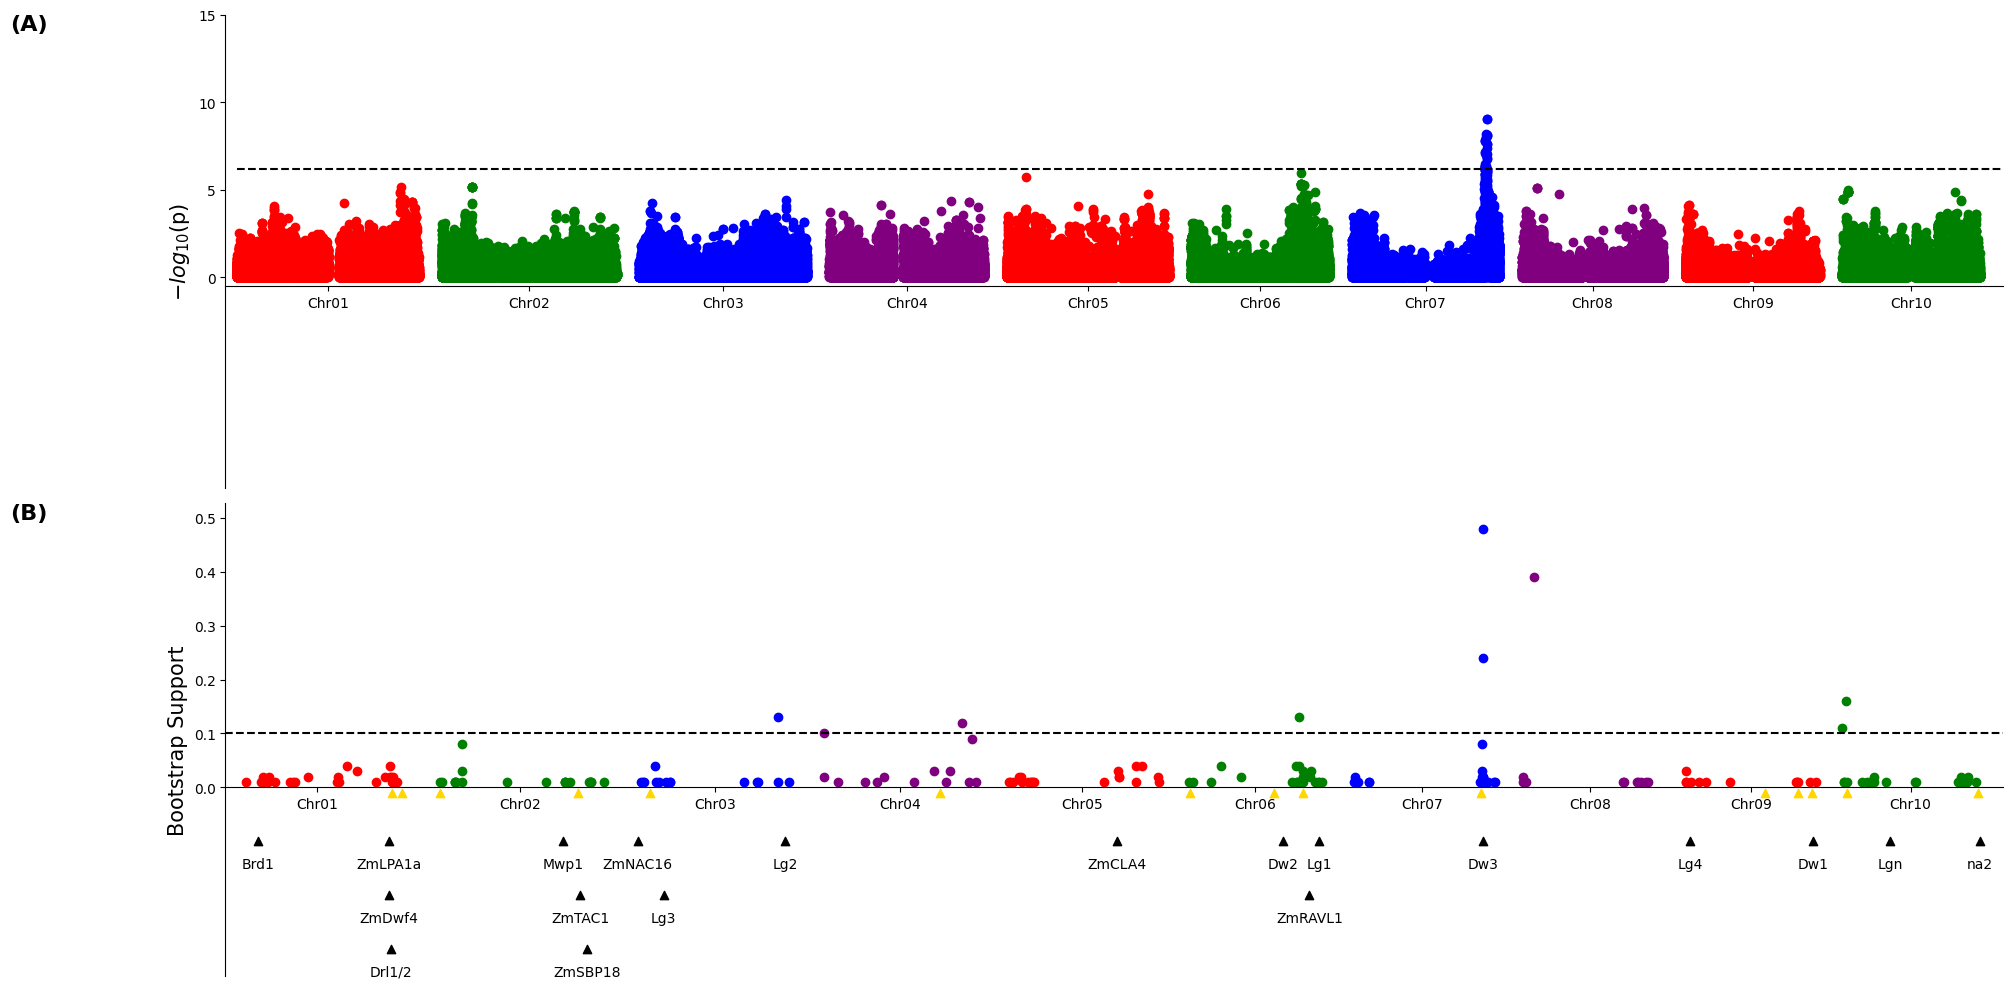

In [ ]:
from IPython.display import Image, display
display(Image(filename="/content/sorghum3d/Fig_2_reproduced.png", width=900))

## 5. Comparison with the authors' published Figure 2

Side-by-side: **left** the author-committed `Figures/Fig_2.png` (reference output from the pinned
commit), **right** this notebook's regenerated figure. Expect the same SNP distribution, threshold
lines, and labeled candidates; small anti-aliasing/label-placement differences are normal.

**日本語:** 著者コミット済みのFigure 2（左）とこのノートブックの再生成結果（右）を比較します。

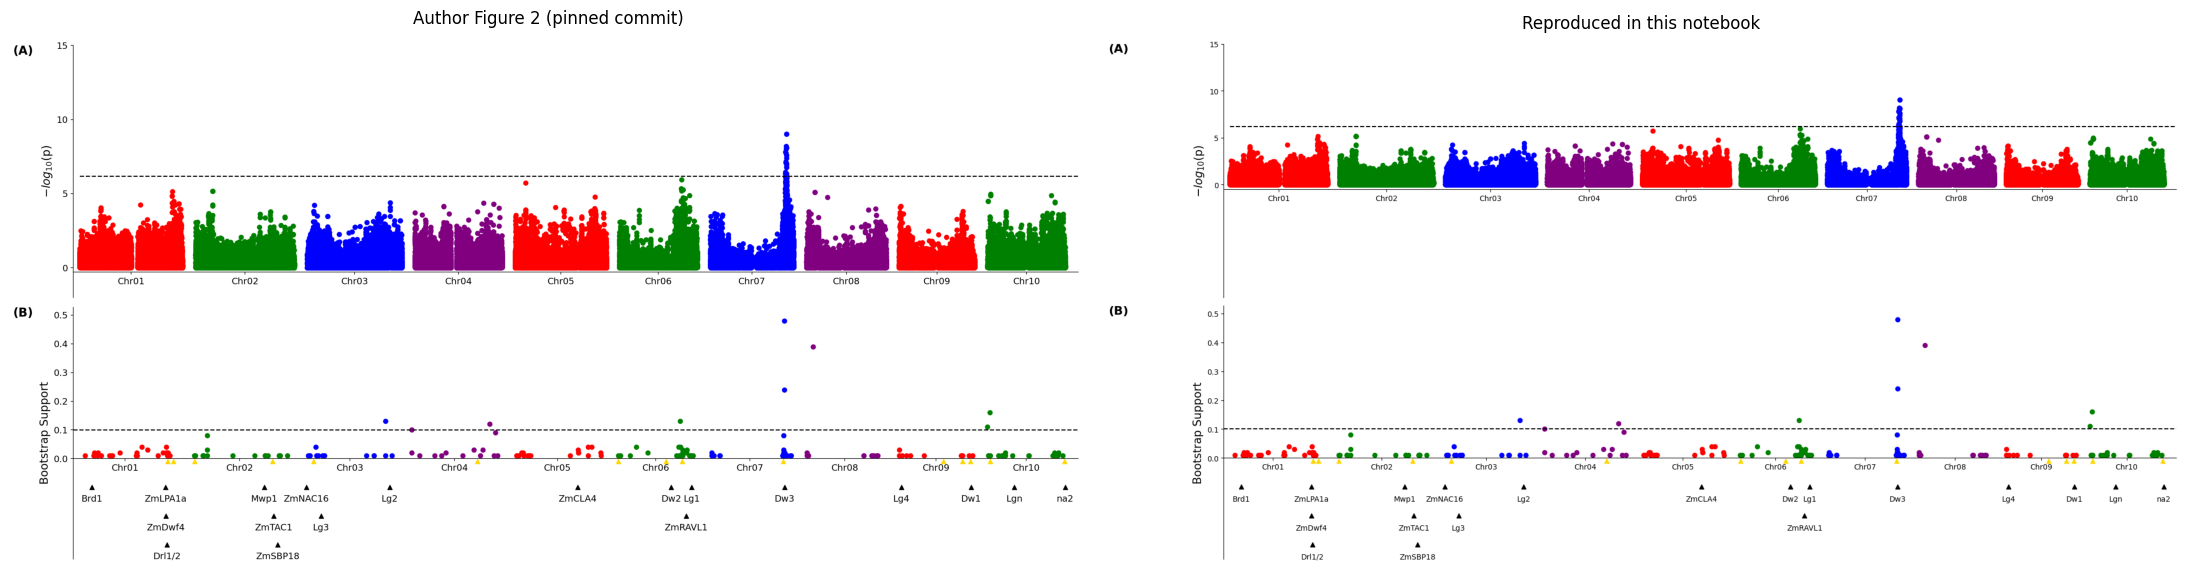

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(22, 6))
axes[0].imshow(plt.imread(f"{DATA}/Figures/Fig_2.png"))
axes[0].set_title("Author Figure 2 (pinned commit)", fontsize=12); axes[0].axis("off")
axes[1].imshow(plt.imread("/content/sorghum3d/Fig_2_reproduced.png"))
axes[1].set_title("Reproduced in this notebook", fontsize=12); axes[1].axis("off")
plt.tight_layout(); plt.show()

## 6. Regenerate Figure 3 with the authors' script (verbatim)

`manhattan_Fig3.py` runs the same parsing per leaf (1–3) with no inter-chromosome gaps, annotating
ZmTAC1 (leaf 1), Dw3/ZmRAVL1 (leaf 2), and Dw3 (leaf 3). Same two adaptations as above; the script
already reads the `FarmCPU_Leaf{1,2,3}_resamp.csv` names directly.

**日本語:** 葉ごとのFarmCPUブートストラップ結果（Figure 3）を著者スクリプトで再生成します。

In [ ]:
src3 = open(f"{DATA}/scripts/manhattan_Fig3.py").read()
assert src3.count("fig.add_subplot('31{}'.format(plotCount))") == 1
src3 = src3.replace("fig.add_subplot('31{}'.format(plotCount))", "fig.add_subplot(3, 1, plotCount)")
plt.show = show_to_save("/content/sorghum3d/Fig_3_reproduced.png")
os.chdir(f"{DATA}/scripts")
try:
    exec(compile(src3, "manhattan_Fig3.py", "exec"), {"__name__": "__main__"})
finally:
    plt.show = orig_show; os.chdir(cwd)
matplotlib.use("module://matplotlib_inline.backend_inline")  # restore notebook display
print("Fig_3_reproduced.png saved")

Fig_3_reproduced.png saved


Display the reproduced Figure 3 (three per-leaf panels), then compare with the author's
`Figures/Fig_3.png`.

**日本語:** 再現したFigure 3を表示し、著者の版と比較します。

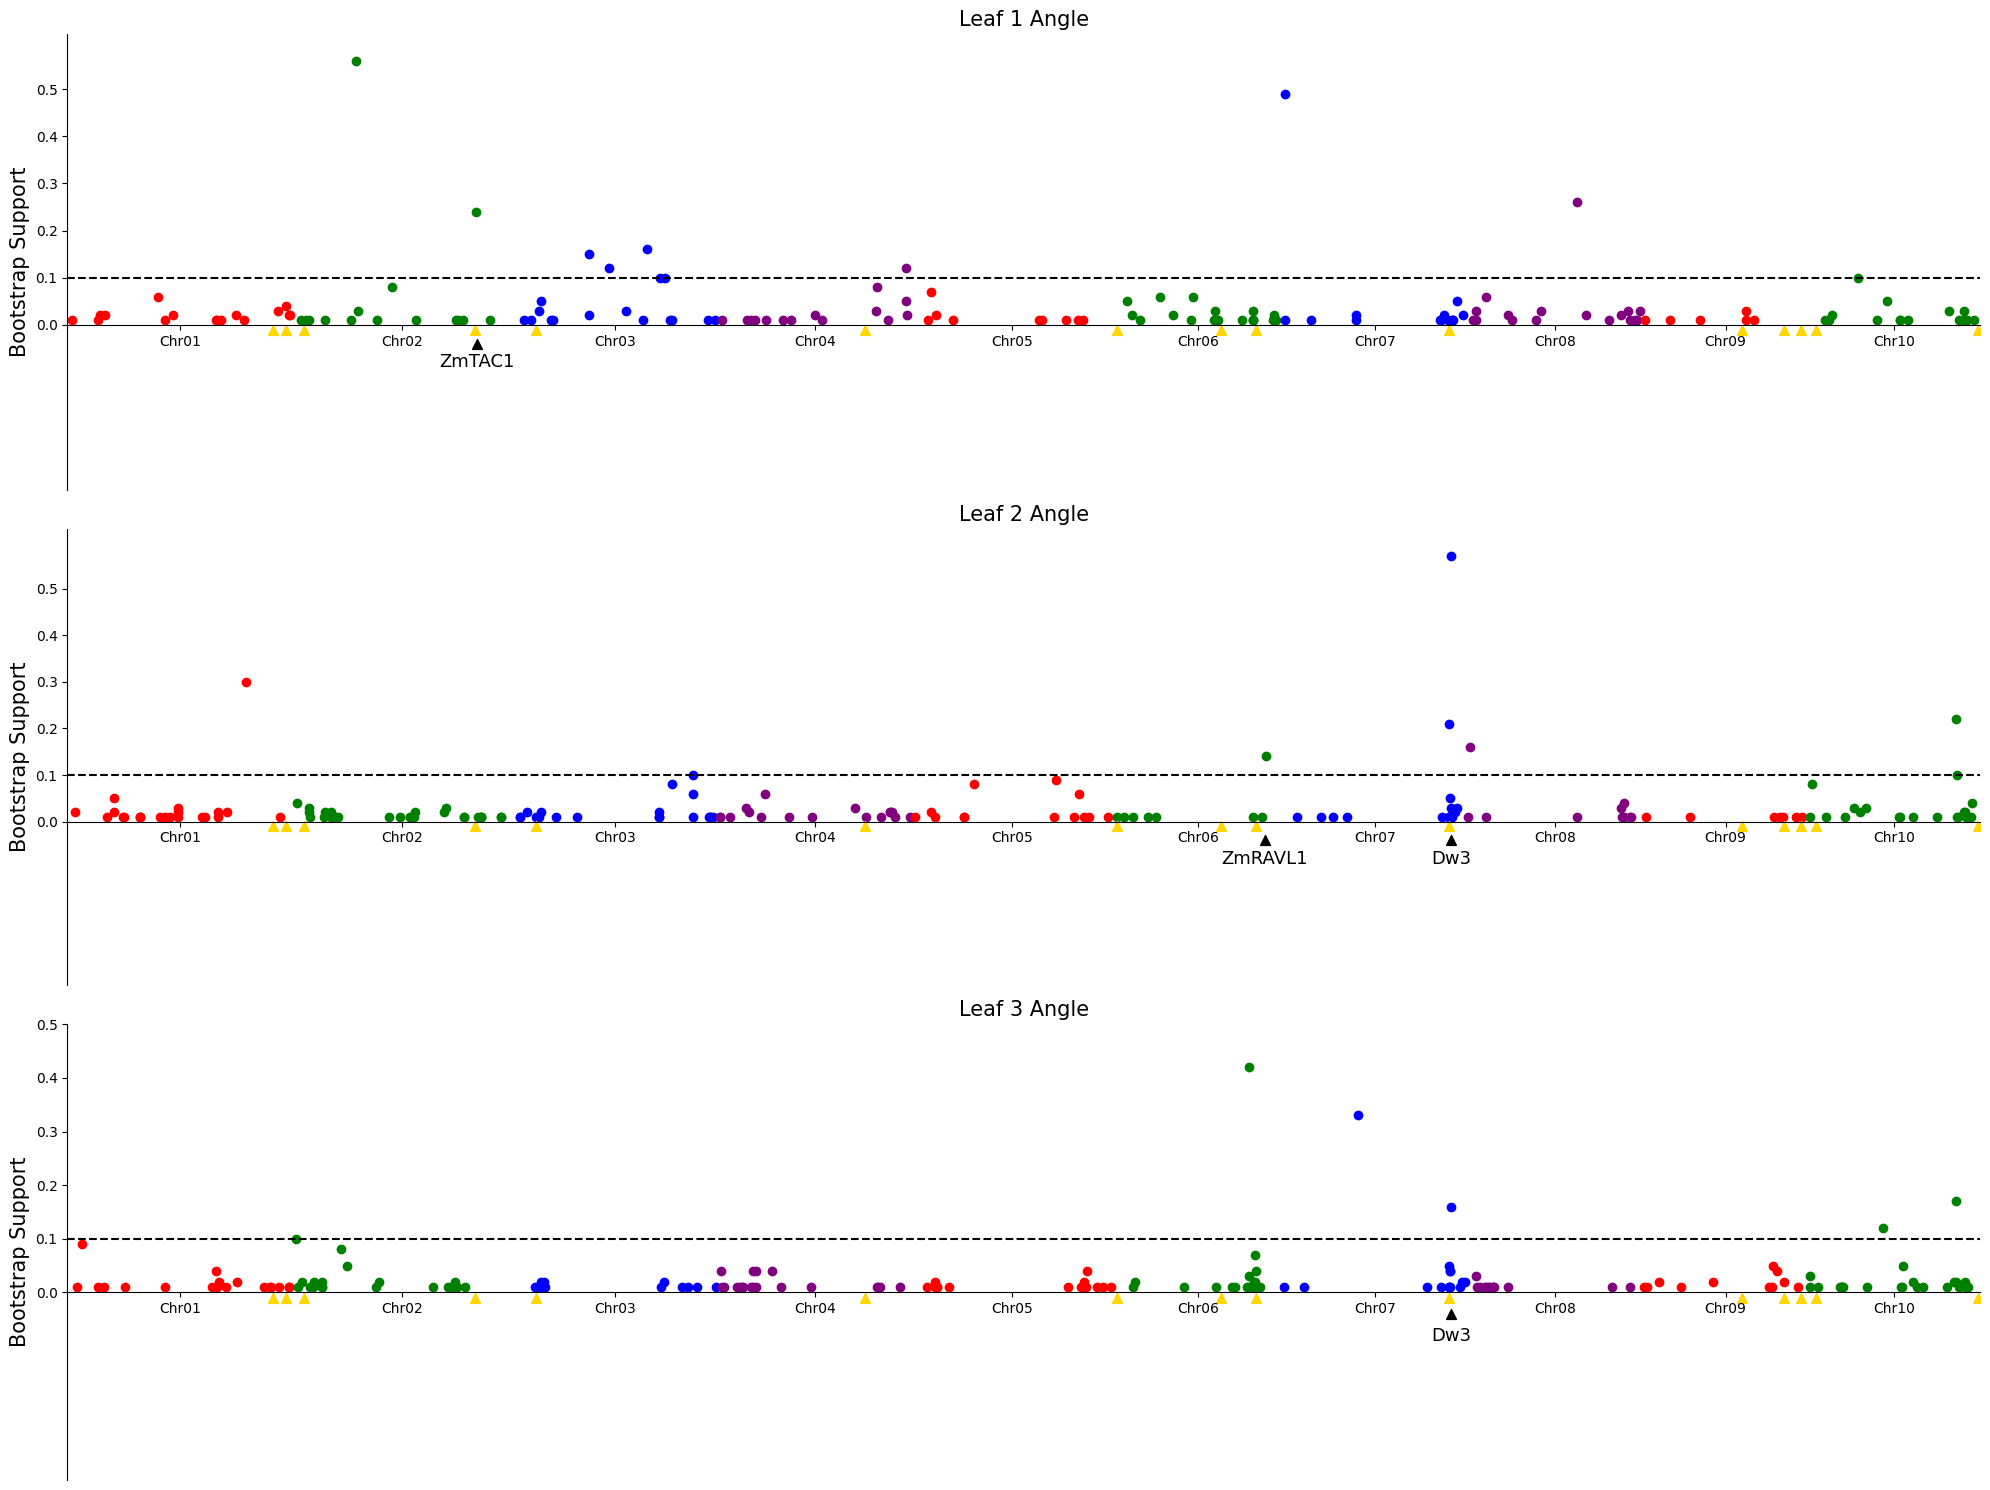

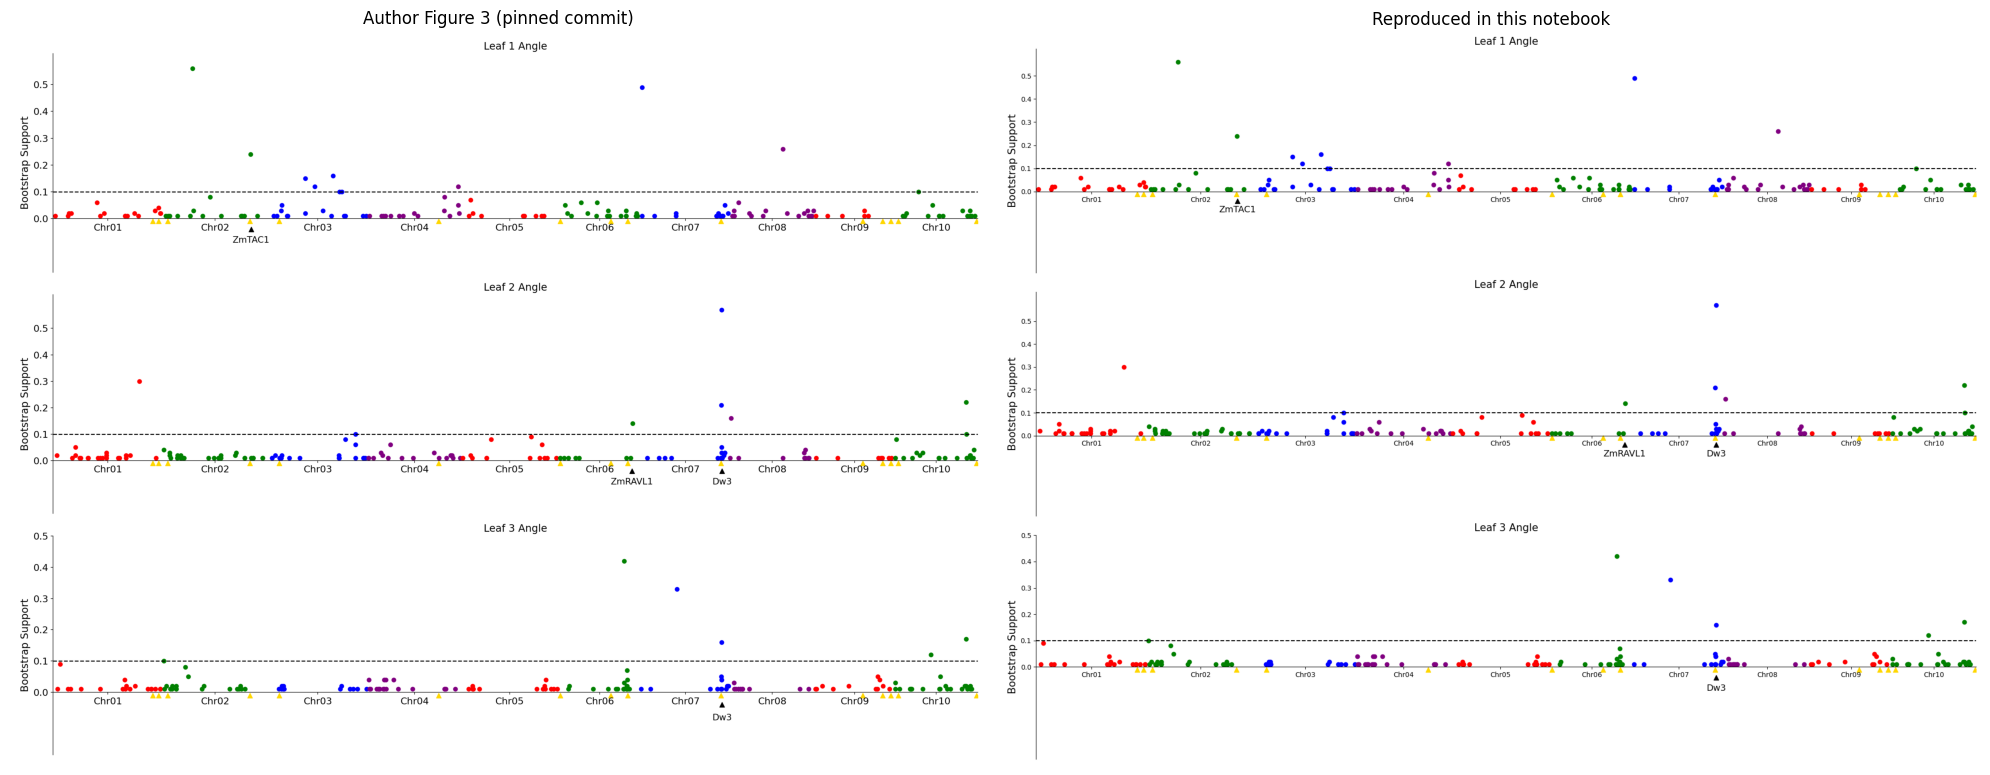

In [ ]:
display(Image(filename="/content/sorghum3d/Fig_3_reproduced.png", width=700))
fig, axes = plt.subplots(1, 2, figsize=(20, 12))
axes[0].imshow(plt.imread(f"{DATA}/Figures/Fig_3.png"))
axes[0].set_title("Author Figure 3 (pinned commit)", fontsize=12); axes[0].axis("off")
axes[1].imshow(plt.imread("/content/sorghum3d/Fig_3_reproduced.png"))
axes[1].set_title("Reproduced in this notebook", fontsize=12); axes[1].axis("off")
plt.tight_layout(); plt.show()

## 7. Quantitative check: stable SNPs per trait

As a compact numeric summary, count SNPs at or above the paper's stability threshold (bootstrap
support > 0.1, i.e. significant in >10 of 100 resamples) per trait, from the authors' resampling
files. The counting rule and threshold are the paper's; this table itself is a notebook-only
addition.

**日本語:** 安定SNP数（支持率>0.1）を形質ごとに数えます（本ノートブック独自の補助集計）。

In [ ]:
rows = []
for label, f in [("Median leaves 1-4", "FarmCPU_Med1to4_resamp.csv"),
                 ("Leaf 1", "FarmCPU_Leaf1_resamp.csv"),
                 ("Leaf 2", "FarmCPU_Leaf2_resamp.csv"),
                 ("Leaf 3", "FarmCPU_Leaf3_resamp.csv")]:
    df = pd.read_csv(f"{DATA}/gwas_results/{f}")
    count_col = [c for c in df.columns if "count" in c.lower() or "resamp" in c.lower() or c.lower() in ("n", "times")]
    count_col = count_col[0] if count_col else df.columns[-1]
    print(f"  {label}: using count column {count_col!r} (columns: {list(df.columns)})")
    support = df[count_col] / 100.0
    rows.append((label, len(df), int((support > 0.1).sum()), float(support.max())))
summary = pd.DataFrame(rows, columns=["trait", "SNPs in resampling file", "stable SNPs (support > 0.1)", "max support"])
print(summary.to_string(index=False))

  Median leaves 1-4: using count column 'Freq' (columns: ['Var1', 'Freq'])
  Leaf 1: using count column 'Freq' (columns: ['Var1', 'Freq'])
  Leaf 2: using count column 'Freq' (columns: ['Var1', 'Freq'])
  Leaf 3: using count column 'Freq' (columns: ['Var1', 'Freq'])
            trait  SNPs in resampling file  stable SNPs (support > 0.1)  max support
Median leaves 1-4                      196                            8         0.48
           Leaf 1                      144                            8         0.56
           Leaf 2                      158                            6         0.57
           Leaf 3                      163                            5         0.42


And the distribution of the published median leaf angles (leaves 1–4) across genotypes — the
phenotype distribution underlying these GWAS panels. This is an additional visualization created
for this notebook, not an author figure. The columns used are auto-detected as the 0–180° numeric
angle columns printed in section 3.

**日本語:** 公開済みの葉1〜4メディアン角度の分布（これらGWASの元になる表現型分布）。

/tmp/ipykernel_2561/3987843320.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([med[c].dropna() for c in angle_cols[:4]], labels=[str(c) for c in angle_cols[:4]])


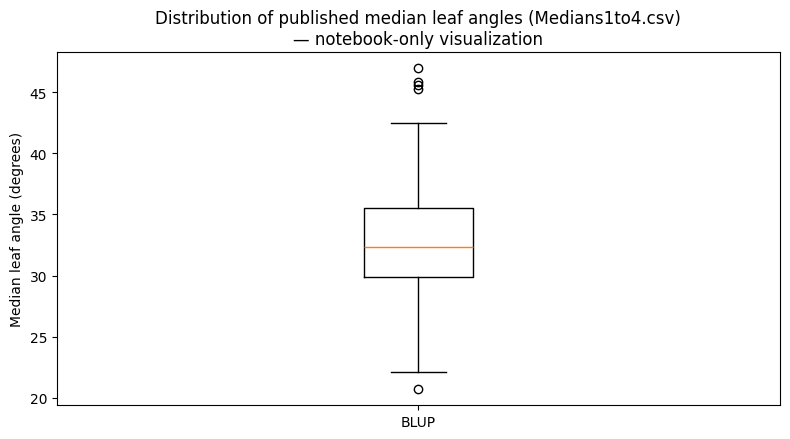

In [ ]:
angle_cols = [c for c in num_cols if med[c].between(0, 180).all()]
assert angle_cols, "no 0-180 degree columns found in Medians1to4.csv"
plt.figure(figsize=(8, 4.5))
plt.boxplot([med[c].dropna() for c in angle_cols[:4]], labels=[str(c) for c in angle_cols[:4]])
plt.ylabel("Median leaf angle (degrees)")
plt.title("Distribution of published median leaf angles (Medians1to4.csv)\n— notebook-only visualization")
plt.tight_layout(); plt.show()

## 8. Interpretation and limitations

**What was reproduced (executed):** Figures 2 and 3 regenerated with the authors' own pinned
scripts and published result files; the phenotype inputs were inspected; stable-SNP counts and the
phenotype distribution summarize the published data. The paper's key findings visible here:
no GEMMA MLM SNP passed the conservative threshold for the aggregate trait (panel A), while FarmCPU
resampling recovered stable loci near **Dw3** (chromosome 7) and **ZmTAC1/UPA2-region** candidates,
with leaf-specific signals for leaves 1–3.

**What was NOT done (out of scope, per pinned evidence):**
- Rerunning GEMMA/FarmCPU — needs the 232,113-SNP filtered genotype matrix from Miao et al. 2020a, not confirmed present in the author repository.
- 3D voxel carving / skeletonization — needs `cropsinsilico/SorghumVoxelCarving` (C++/Qt/OpenCV/DGtal) and the 34.1 GB Zenodo image archive (10.5281/zenodo.4426620).

**日本語のまとめ:** 本ノートブックは論文のGWAS結果図（Figure 2・3）を著者コードで再現しました。GWAS自体の再計算と3D再構築パイプラインは範囲外です。

## References
- Paper: PeerJ 9:e12628 (2021), DOI 10.7717/peerj.12628
- Code: https://github.com/mtross2/Sorghum-3D-Reconstruction @ `1b1631ae1d7231b5ceedb98d2c31d439c8cbfe98` (MIT)
- Data archive: https://doi.org/10.5281/zenodo.4426620 (not downloaded here)
- Investigation metadata via PhenoPaper API (prior research guidance; not primary proof).